# NIVAL airborne lidar versus NISAR dSWE, using SnowIn

This notebook adapts the NISAR comparison in Zach Hoppinen's [tc_brief_nival_validation](https://github.com/ZachHoppinen/tc_brief_nival_validation) repository to SnowIn. It targets Mores Creek Summit, Idaho, ASC-077, 7–19 February 2026. The reference analysis uses the operational NISAR L2 GUNW at 80 m and NIVAL lidar snow-depth rasters from 7 and 22 February. The processing output can be written in the reference repository's existing NetCDF layout so its Figure 2 plotting function can be reused unchanged.

The workflow removes the scene median phase before conversion; computes dSWE with SnowIn's canonical kernel, product wavelength and local incidence angle; differences the two lidar surfaces on their native grid; masks |dHS| ≥ 1.5 m there; average-resamples the gated change to the GUNW grid; anchors dSWE to median lidar-implied SWE at 147 kg/m³; and reports correlation, RMSE, fitted density and sample count by coherence gate. The phase datum removal happens before the angle-dependent conversion. The absolute SWE anchor is a separate constant offset that does not affect correlation. Zach's current code uses fixed wavelength 0.238 m; this notebook uses the GUNW metadata wavelength. For direct comparison, `dswe` follows Zach's source-phase polarity (the negative of SnowIn's canonical dSWE); the saved product also retains `dswe_snowin_canonical` so the polarity difference is visible.

The [EGUsphere preprint](https://doi.org/10.5194/egusphere-2026-5140) reports all-pixel n=4,976, r=0.82 and centered RMSD=19 mm; above coherence 0.2 it reports r=0.93 and 12 mm, and above 0.4 r=0.96 and 9 mm. It describes the fitted density as 141 kg/m³ for all pixels and about 154–160 kg/m³ across the 0.2/0.4 gates. The cloned code repository's README instead lists densities 150 / 157 / 161 / 162 kg/m³ for all / >0.2 / >0.4 / >0.5. That code-versus-preprint difference should be resolved by running the checked-out analysis; this notebook calculates the slope and does not force either set. Zach's detailed stats script also includes >0.3, elevation deramping, scale decomposition, canopy/burn strata and local correlations, which need more inputs and are outside this minimal port.

The inputs can be downloaded with `python -m pip install -e '.[gunw]'` followed by `python scripts/download_nival_nisar_inputs.py --inputs all --interactive-login`, or stage lidar, GUNW and DEM separately with `--inputs lidar`, `--inputs gunw`, and `--inputs dem`. This fetches just the two snow-depth GeoTIFF assets from the free [NSIDC NIVAL collection](https://doi.org/10.5067/DPFDH2M49DQG), the [ASF GUNW](https://doi.org/10.5067/NIL2GUNW-P1) (about 2.5 GB), and the one Copernicus DEM tile covering the Mores Creek AOI. A free NASA Earthdata Login is required for lidar and GUNW; the interactive option bypasses a stale local `.netrc`. Data go under `~/.cache/snowin/nival_nisar/` by default.

The correction screens carried in the GUNW are not applied, matching Zach's stated choice. Numerical differences can result from wavelength, LIA derivation, resampling, or valid-data masks.

In [1]:
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd
import rioxarray
from pyproj import Transformer
import xarray as xr
from rasterio.enums import Resampling
WORKING_DIR = Path.cwd().resolve()
REPO_ROOT = next((parent for parent in (WORKING_DIR, *WORKING_DIR.parents)
                  if (parent / 'src' / 'snowin').is_dir()), None)
if REPO_ROOT is None:
    raise RuntimeError('Could not find SnowIn src/snowin; open this notebook from a SnowIn checkout.')
SOURCE_DIR = REPO_ROOT / 'src'
sys.path.insert(0, str(SOURCE_DIR))
from snowin import compute_dswe
from snowin.io import add_gunw_incidence, open_gunw

DATA_DIR = Path(os.environ.get('SNOWIN_NIVAL_DATA_DIR', Path.home() / '.cache' / 'snowin' / 'nival_nisar')).expanduser()
GUNW = DATA_DIR / 'gunw' / 'NISAR_L2_PR_GUNW_012_077_A_024_013_4000_SH_20260207T124619_20260207T124654_20260219T124619_20260219T124654_P05023_N_F_J_001.h5'
LIDAR_FEB07 = DATA_DIR / 'lidar' / 'NIVAL_MCS_Lidar_20260207_SD_v01.tif'
LIDAR_FEB22 = DATA_DIR / 'lidar' / 'NIVAL_MCS_Lidar_20260222_SD_v01.tif'
COP30_DEM = Path(os.environ.get('SNOWIN_NIVAL_COP30_DEM', DATA_DIR / 'dem' / 'Copernicus_DSM_COG_10_N43_00_W116_00_DEM.tif')).expanduser()
SNOW_DENSITY_KG_M3, WATER_DENSITY_KG_M3 = 147.0, 1000.0
DHS_GATE_M = 1.5
for path in (GUNW, LIDAR_FEB07, LIDAR_FEB22, COP30_DEM):
    if not path.is_file():
        raise FileNotFoundError(f'Missing input: {path}')

In [2]:
# Open the operational full-frame product, then crop to Zach's Mores Creek AOI.
pair = open_gunw(GUNW, chunks=None, progress=True)
aoi = (-115.745, 43.898, -115.620, 43.993)  # west, south, east, north, EPSG:4326
epsg = int(pair['spatial_ref'].attrs['epsg_code'])
to_projected = Transformer.from_crs(4326, epsg, always_xy=True).transform
west, south, east, north = aoi
projected = [to_projected(lon, lat) for lon in (west, east) for lat in (south, north)]
x_bounds = (min(point[0] for point in projected), max(point[0] for point in projected))
y_bounds = (min(point[1] for point in projected), max(point[1] for point in projected))
x_index = np.flatnonzero((pair.x.values >= x_bounds[0]) & (pair.x.values <= x_bounds[1]))
y_index = np.flatnonzero((pair.y.values >= y_bounds[0]) & (pair.y.values <= y_bounds[1]))
if not x_index.size or not y_index.size:
    raise ValueError('Mores AOI does not intersect the GUNW grid')
pair = pair.isel(x=x_index, y=y_index)
# Use the single AOI GLO-30 tile; passing it explicitly avoids staging the full-frame DEM.
pair = add_gunw_incidence(pair, GUNW, dem_source='cop30', cop30_dem=COP30_DEM, progress=True)
phase, coherence, lia = pair['phase'], pair['coherence'], pair['incidence_angle']
print({'reference_time': pair.attrs.get('reference_time'), 'secondary_time': pair.attrs.get('secondary_time'), 'wavelength_m': pair.attrs.get('wavelength_m'), 'phase_convention': phase.attrs.get('phase_difference_definition'), 'lia_source': lia.attrs.get('incidence_angle_source'), 'shape': phase.shape, 'posting_m': float(abs(phase.x.values[1] - phase.x.values[0]))})

[snowin] opening GUNW phase data from NISAR_L2_PR_GUNW_012_077_A_024_013_4000_SH_20260207T124619_20260207T124654_20260219T124619_20260219T124654_P05023_N_F_J_001.h5


[snowin] starting explicit GUNW incidence calculation


[snowin] preparing DEM for local incidence


[snowin] reading GUNW radar-grid LOS vectors


[snowin] computing terrain-surface incidence from DEM and GUNW LOS


[snowin] interpolating GUNW LOS vectors onto the DEM surface


[snowin] deriving terrain normals and incidence angles


[snowin] incidence_angle appended to SnowIn dataset


{'reference_time': '2026-02-07T12:46:19Z', 'secondary_time': '2026-02-19T12:46:19Z', 'wavelength_m': 0.2419632429378531, 'phase_convention': 'secondary_minus_reference', 'lia_source': 'COP30 DEM plus NISAR GUNW radar-grid LOS', 'shape': (134, 127), 'posting_m': 80.0}


In [3]:
# SnowIn's incidence adapter has already supplied local angle in radians.
phase_zeroed = (phase - phase.median(skipna=True)).rename('phase')
phase_zeroed.attrs = dict(phase.attrs)
phase_zeroed.attrs.update({'units': 'rad', 'phase_difference_definition': 'secondary_minus_reference'})
dswe_snowin_canonical = compute_dswe(phase_zeroed, lia, wavelength_m=float(pair.attrs['wavelength_m']))
# Zach applies the same positive Leinss factor to the source GUNW orientation.
# SnowIn normalizes phase to secondary-minus-reference, so flip its dSWE output
# for a like-for-like reproduction and keep both sign conventions explicit.
dswe_unanchored = (-dswe_snowin_canonical).rename('dswe')
dswe_unanchored.attrs = dict(dswe_snowin_canonical.attrs)
dswe_unanchored.attrs.update({'phase_difference_definition': 'reference_minus_secondary', 'comparison_sign_adjustment': 'negative of SnowIn canonical dSWE to match Zach source-phase polarity'})
print('finite phase/dSWE pixels:', int(np.isfinite(dswe_unanchored.values).sum()))

finite phase/dSWE pixels: 17018


In [4]:
# Difference and gate dHS on the native lidar grid before average-resampling to 80 m,
# matching Zach's treatment of void/canopy outliers.
spatial_ref = pair['spatial_ref'].attrs
crs = spatial_ref.get('spatial_ref') or spatial_ref.get('crs_wkt')
if crs is None:
    raise ValueError('GUNW spatial_ref has no CRS text')
grid = xr.DataArray(np.zeros(phase.shape, dtype=np.float32), dims=phase.dims, coords={'y': phase.y, 'x': phase.x}, name='grid').rio.write_crs(crs)
depth_earlier = rioxarray.open_rasterio(LIDAR_FEB07, masked=True).squeeze()
depth_later = rioxarray.open_rasterio(LIDAR_FEB22, masked=True).squeeze()
if depth_earlier.shape != depth_later.shape or depth_earlier.rio.crs != depth_later.rio.crs or depth_earlier.rio.transform() != depth_later.rio.transform():
    raise ValueError('The two native lidar rasters must share a grid before differencing')
native_dhs = depth_later - depth_earlier
native_dhs = native_dhs.where((native_dhs > -DHS_GATE_M) & (native_dhs < DHS_GATE_M)).rio.write_nodata(np.nan)
dhs = native_dhs.rio.reproject_match(grid, resampling=Resampling.average).rename('dhs').assign_coords(y=phase.y, x=phase.x)
dhs.attrs.update({'units': 'm', 'interval': '2026-02-07 to 2026-02-22'})
common = np.isfinite(dswe_unanchored.values) & np.isfinite(dhs.values)
if not common.any():
    raise ValueError('No overlapping valid NISAR dSWE and lidar dHS pixels; check CRS, AOI, and nodata')
lidar_swe = dhs.values * SNOW_DENSITY_KG_M3 / WATER_DENSITY_KG_M3
anchor_m = np.nanmedian(lidar_swe[common] - dswe_unanchored.values[common])
dswe = (dswe_unanchored + anchor_m).rename('dswe')
print(f'common pixels: {int(common.sum()):,}; dSWE constant anchor: {anchor_m * 1000:.2f} mm')

common pixels: 4,976; dSWE constant anchor: 37.38 mm


In [5]:
def comparison_metrics(mask=None):
    valid = common.copy()
    if mask is not None:
        valid &= np.asarray(mask, dtype=bool)
    n = int(valid.sum())
    if n < 3:
        return {'n': n, 'r': np.nan, 'centered_rmsd_mm': np.nan, 'density_kg_m3': np.nan}
    x, h = dswe.values[valid], dhs.values[valid]
    lidar = h * SNOW_DENSITY_KG_M3 / WATER_DENSITY_KG_M3
    centered_offset = np.median(lidar - x)
    centered_rmsd_mm = float(np.sqrt(np.mean((x + centered_offset - lidar) ** 2)) * 1000)
    return {'n': n, 'r': float(np.corrcoef(x, h)[0, 1]), 'centered_rmsd_mm': centered_rmsd_mm, 'density_kg_m3': float(np.polyfit(h, x, 1)[0] * WATER_DENSITY_KG_M3)}
gates = [('all pixels', None)] + [(f'coherence > {t:.1f}', coherence.values > t) for t in (0.2, 0.3, 0.4, 0.5)]
rows = []
for label, gate in gates:
    row = comparison_metrics(gate)
    row.update({'gate': label, 'percent_of_valid': 100 * row['n'] / int(common.sum())})
    rows.append(row)
pd.DataFrame(rows)[['gate', 'r', 'centered_rmsd_mm', 'density_kg_m3', 'n', 'percent_of_valid']]

,gate,r,centered_rmsd_mm,density_kg_m3,n,percent_of_valid
0,all pixels,0.817332,19.018720,143.439846,4976,100.000000
1,coherence > 0.2,0.928168,11.989418,156.384582,2891,58.098875
2,coherence > 0.3,0.949367,10.390037,158.748875,1843,37.037781
3,coherence > 0.4,0.962289,9.501175,162.094311,1004,20.176849
4,coherence > 0.5,0.958902,9.702113,163.178807,463,9.304662


## Quantitative comparison: SnowIn and Zach's 80 m results

Zach's values below are the rounded values in the reference repository README.
SnowIn computes its metrics from this notebook's current inputs. The error
columns are close comparators: SnowIn reports median-centered RMSD, while the
README reports RMSE. Density is the fitted dSWE-versus-dHS slope. Differences
are shown directly rather than calibrating SnowIn to force agreement.

In [6]:
zach_80m = pd.DataFrame([
    {"gate": "all pixels", "zach_r": 0.82, "zach_rmse_mm": 19, "zach_density_kg_m3": 150, "zach_n": 4976},
    {"gate": "coherence > 0.2", "zach_r": 0.93, "zach_rmse_mm": 12, "zach_density_kg_m3": 157, "zach_n": 2891},
    {"gate": "coherence > 0.4", "zach_r": 0.96, "zach_rmse_mm": 9, "zach_density_kg_m3": 161, "zach_n": 1004},
    {"gate": "coherence > 0.5", "zach_r": 0.96, "zach_rmse_mm": 9, "zach_density_kg_m3": 162, "zach_n": 463},
])
snowin_80m = pd.DataFrame(rows)
comparison_80m = zach_80m.merge(snowin_80m, on="gate", how="left")
comparison_80m["delta_r"] = comparison_80m["r"] - comparison_80m["zach_r"]
comparison_80m["delta_error_mm"] = comparison_80m["centered_rmsd_mm"] - comparison_80m["zach_rmse_mm"]
comparison_80m["delta_density_kg_m3"] = comparison_80m["density_kg_m3"] - comparison_80m["zach_density_kg_m3"]
comparison_80m["delta_n"] = comparison_80m["n"] - comparison_80m["zach_n"]
comparison_80m = comparison_80m.rename(columns={
    "n": "snowin_n", "zach_n": "zach_n",
    "r": "snowin_r", "zach_r": "zach_r",
    "centered_rmsd_mm": "snowin_centered_rmsd_mm",
    "density_kg_m3": "snowin_density_kg_m3",
})
display(comparison_80m[[
    "gate", "snowin_n", "zach_n", "delta_n",
    "snowin_r", "zach_r", "delta_r",
    "snowin_centered_rmsd_mm", "zach_rmse_mm", "delta_error_mm",
    "snowin_density_kg_m3", "zach_density_kg_m3", "delta_density_kg_m3",
]].round({"snowin_r": 3, "zach_r": 2, "delta_r": 3, "snowin_centered_rmsd_mm": 2, "delta_error_mm": 2, "snowin_density_kg_m3": 1, "zach_density_kg_m3": 0, "delta_density_kg_m3": 1}))

,gate,snowin_n,zach_n,delta_n,snowin_r,zach_r,delta_r,snowin_centered_rmsd_mm,zach_rmse_mm,delta_error_mm,snowin_density_kg_m3,zach_density_kg_m3,delta_density_kg_m3
0,all pixels,4976,4976,0,0.817,0.82,-0.003,19.02,19,0.02,143.4,150,-6.6
1,coherence > 0.2,2891,2891,0,0.928,0.93,-0.002,11.99,12,-0.01,156.4,157,-0.6
2,coherence > 0.4,1004,1004,0,0.962,0.96,0.002,9.50,9,0.50,162.1,161,1.1
3,coherence > 0.5,463,463,0,0.959,0.96,-0.001,9.70,9,0.70,163.2,162,1.2


## Save SnowIn output for the comparison plots

The next cell writes SnowIn's 80 m product in Zach's expected NetCDF layout. The
plotting sections then call Zach's unchanged Figure 2 function on that product
and show his checked-in original Figure 2 immediately below for visual
comparison. The quantitative table above compares SnowIn's computed metrics
with the rounded values in his repository README.

The final sections compare the independent 20 m ISCE3 ICU result with
NIVAL lidar and show Zach's original Figure 3 beneath it. Zach unwraps the
same delivered 20 m wrapped interferogram with SNAPHU; ICU and SNAPHU can
produce different phase fields, so that comparison is diagnostic rather than
an algorithm-for-algorithm match. Set NIVAL_REFERENCE_REPO to a local checkout
of Zach's repository before launching Jupyter to render his plotting code and
load the original checked-in figures.

In [7]:
import os

# Persist a SnowIn-native 80 m result; optionally stage a copy at Zach's expected path.
dem_path = Path(pair.attrs['dem_input'])
elevation = (rioxarray.open_rasterio(dem_path, masked=True).squeeze()
             .rio.reproject_match(grid, resampling=Resampling.bilinear)
             .rename('elevation'))
lia_degrees = (np.rad2deg(lia).rename('lia'))
lia_degrees.attrs.update({'units': 'degrees', 'incidence_angle_reference': 'local'})
snowin_product = xr.Dataset(
    {'dswe': (('y', 'x'), dswe.values),
     'dswe_snowin_canonical': (('y', 'x'), dswe_snowin_canonical.values),
     'dhs': (('y', 'x'), dhs.values),
     'coherence': (('y', 'x'), coherence.values),
     'elevation': (('y', 'x'), elevation.values),
     'lia': (('y', 'x'), lia_degrees.values)},
    coords={'y': phase.y.values, 'x': phase.x.values},
    attrs={'crs_epsg': epsg, 'posting_m': float(abs(phase.x.values[1] - phase.x.values[0])),
           'processing': 'SnowIn open_gunw, add_gunw_incidence, and compute_dswe',
           'wavelength_m': float(pair.attrs['wavelength_m']),
           'lidar_snow_density_kg_m3': SNOW_DENSITY_KG_M3})
snowin_output = DATA_DIR / 'snowin_nival_comparison_80m.nc'
snowin_product.to_netcdf(snowin_output)
print('SnowIn product:', snowin_output)

reference_repo = os.environ.get('NIVAL_REFERENCE_REPO')
if reference_repo:
    reference_repo = Path(reference_repo).expanduser().resolve()
    if not (reference_repo / 'src/nival/paper_figures.py').is_file():
        raise FileNotFoundError(f'Not a tc_brief_nival_validation checkout: {reference_repo}')
    compat_output = reference_repo / 'outputs/retrieval/dswe_dhs_operational.nc'
    compat_output.parent.mkdir(parents=True, exist_ok=True)
    snowin_product.to_netcdf(compat_output)
    print('Zach-compatible product:', compat_output)
    print("The following notebook cells render Zach's unchanged Figure 2 function inline.")
else:
    print('Set NIVAL_REFERENCE_REPO to also export the Zach-compatible product for his Figure 2 plotting code.')

SnowIn product: /private/tmp/snowin_nival_nisar/snowin_nival_comparison_80m.nc
Zach-compatible product: /private/tmp/tc_brief_nival_validation/outputs/retrieval/dswe_dhs_operational.nc
The following notebook cells render Zach's unchanged Figure 2 function inline.


## Visual comparison: 80 m operational product

The first plot uses Zach's unchanged Figure 2 plotting function with the
SnowIn-derived NetCDF. The next image is the original Figure 2 PNG tracked in
Zach's repository, read from Git rather than from its working directory (which
may contain a regenerated SnowIn plot).

all r=0.82 n=4976; high-coh r=0.96 n=463


saved -> /private/tmp/snowin_nival_nisar/inline_figures/fig2_results.png


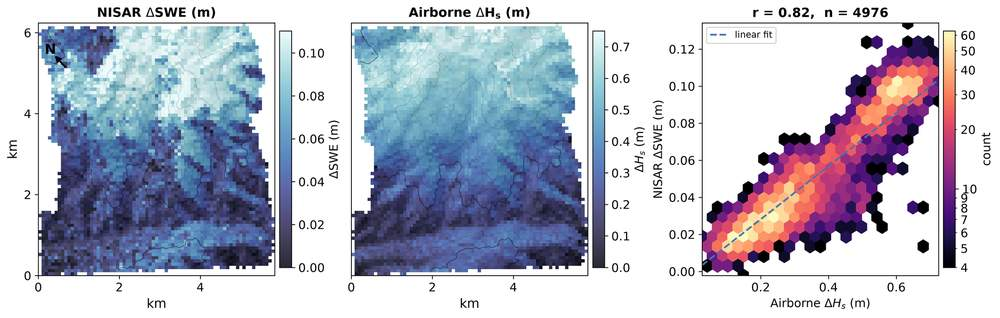

In [8]:
from io import BytesIO
from PIL import Image as PILImage
from IPython.display import Image, display

def display_compact_plot(image_bytes, alt):
    """Render an inline JPEG preview to keep the notebook portable."""
    with PILImage.open(BytesIO(image_bytes)) as source_image:
        image = source_image.convert("RGB")
    max_width = 1000
    if image.width > max_width:
        height = round(image.height * max_width / image.width)
        image = image.resize((max_width, height), PILImage.Resampling.LANCZOS)
    buffer = BytesIO()
    image.save(buffer, format="JPEG", quality=65, optimize=True)
    display(Image(data=buffer.getvalue(), format="jpeg", alt=alt))

reference_repo = Path(os.environ.get("NIVAL_REFERENCE_REPO", "")).expanduser().resolve()
if not (reference_repo / "src/nival/paper_figures.py").is_file():
    raise FileNotFoundError("Set NIVAL_REFERENCE_REPO to a checkout of tc_brief_nival_validation.")

sys.path.insert(0, str(reference_repo / "src"))
from nival import paths as zach_paths
from nival.paper_figures import results_figure

# Redirect only the generated plot; do not overwrite Zach's reference image.
inline_figure_dir = DATA_DIR / "inline_figures"
inline_figure_dir.mkdir(parents=True, exist_ok=True)
original_figure_dir = zach_paths.FIGURES_DIR
zach_paths.FIGURES_DIR = inline_figure_dir
try:
    results_figure()
finally:
    zach_paths.FIGURES_DIR = original_figure_dir

snowin_figure2 = inline_figure_dir / "fig2_results.png"
display_compact_plot(snowin_figure2.read_bytes(), "Zach Figure 2 plotting code applied to SnowIn output")

### Zach's original Figure 2

This is the source-controlled figure from Zach's checkout, shown beneath the
same plotting code applied to SnowIn output.

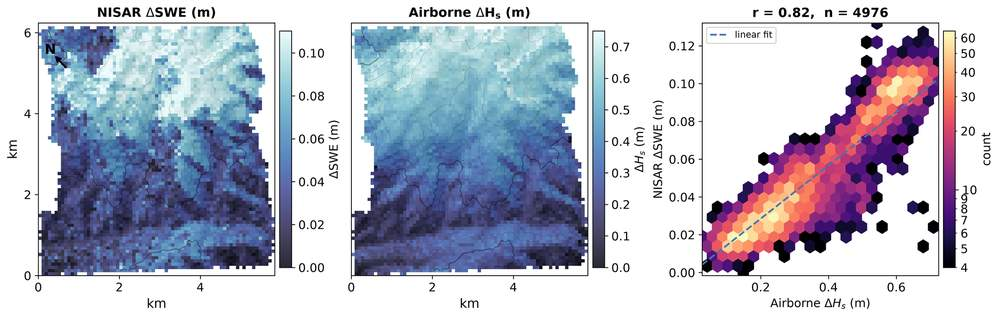

In [9]:
import subprocess

zach_fig2_bytes = subprocess.check_output([
    "git", "-C", str(reference_repo), "show", "HEAD:figures/fig2_results.png"
])
display_compact_plot(zach_fig2_bytes, "Original Zach Figure 2 from Git")

## 20 m diagnostic: SnowIn with independent ISCE3 ICU

When the separate ISCE3 ICU unwrap products are present, this section compares
their SnowIn dSWE to lidar on the 20 m grid, reports the scene-wide metrics,
and plots both fields after centering them to their scene medians, matching Zach's departure-from-scene-mean presentation. The original Zach Figure 3 follows below. His Figure 3
uses SNAPHU on the delivered wrapped GUNW layer; our diagnostic uses ISCE3 ICU.

In [10]:
from pathlib import Path

twenty_product_path = Path(os.environ.get(
    "SNOWIN_NIVAL_20M_DSWE", REPO_ROOT / "outputs/nival_nisar/snowin_20m_dswe.nc"
)).expanduser()
twenty_phase_path = Path(os.environ.get(
    "SNOWIN_NIVAL_20M_PHASE", REPO_ROOT / "outputs/nival_nisar/isce3_icu_20m_unwrapped.tif"
)).expanduser()

if twenty_product_path.is_file() and twenty_phase_path.is_file():
    with xr.open_dataset(twenty_product_path) as twenty_ds:
        snowin_dswe_20m = twenty_ds["dswe"].load()
    phase_grid_20m = rioxarray.open_rasterio(twenty_phase_path, masked=True).squeeze()
    dhs_20m = native_dhs.rio.reproject_match(phase_grid_20m, resampling=Resampling.average)
    dswe_20m_values = snowin_dswe_20m.values
    dhs_20m_values = dhs_20m.values
    valid_20m = np.isfinite(dswe_20m_values) & np.isfinite(dhs_20m_values)
    lidar_swe_20m = dhs_20m_values * SNOW_DENSITY_KG_M3 / WATER_DENSITY_KG_M3
    centered_offset_20m = np.median(lidar_swe_20m[valid_20m] - dswe_20m_values[valid_20m])
    centered_rmsd_20m_mm = float(np.sqrt(np.mean(
        (dswe_20m_values[valid_20m] + centered_offset_20m - lidar_swe_20m[valid_20m]) ** 2
    )) * 1000)
    r_20m = float(np.corrcoef(dswe_20m_values[valid_20m], dhs_20m_values[valid_20m])[0, 1])
    density_20m = float(np.polyfit(
        dhs_20m_values[valid_20m], dswe_20m_values[valid_20m], 1
    )[0] * WATER_DENSITY_KG_M3)
    twenty_m_available = True
    twenty_m_comparison = pd.DataFrame([
        {"workflow": "Zach, SNAPHU unfiltered", "r": 0.75, "valid_n": np.nan,
         "centered_rmsd_mm": np.nan, "fitted_density_kg_m3": np.nan},
        {"workflow": "Zach, Goldstein-filtered variant", "r": 0.80, "valid_n": np.nan,
         "centered_rmsd_mm": np.nan, "fitted_density_kg_m3": np.nan},
        {"workflow": "SnowIn, ISCE3 ICU", "r": r_20m, "valid_n": int(valid_20m.sum()),
         "centered_rmsd_mm": centered_rmsd_20m_mm, "fitted_density_kg_m3": density_20m},
    ])
    display(twenty_m_comparison.round(2))
else:
    twenty_m_available = False
    print("20 m plot skipped: run scripts/unwrap_gunw_20m_isce3.py and scripts/derive_unwrapped_gunw_dswe.py first.")

,workflow,r,valid_n,centered_rmsd_mm,fitted_density_kg_m3
0,"Zach, SNAPHU unfiltered",0.75,NaN,NaN,NaN
1,"Zach, Goldstein-filtered variant",0.80,NaN,NaN,NaN
2,"SnowIn, ISCE3 ICU",0.72,77178.0,23.28,122.56


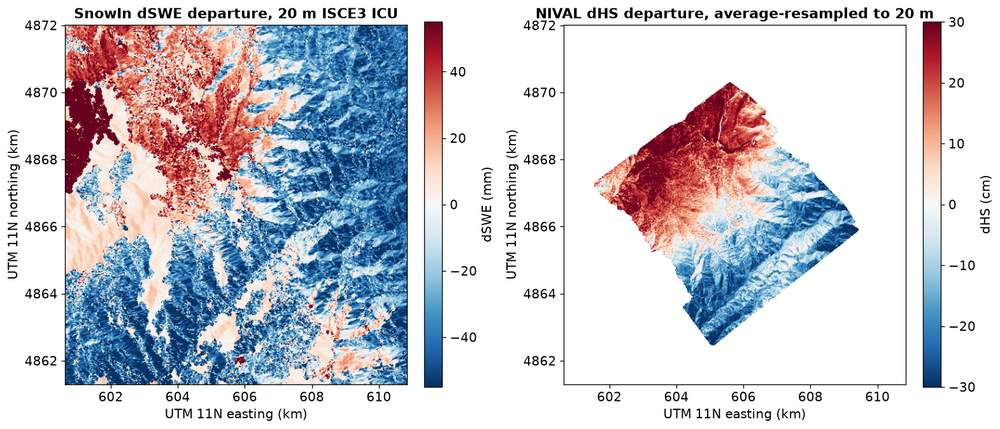

In [11]:
if twenty_m_available:
    from io import BytesIO
    import matplotlib.pyplot as plt
    # Center both fields to show spatial departures, matching Zach's Figure 3.
    dswe_20m_departure = dswe_20m_values - np.nanmedian(dswe_20m_values[valid_20m])
    dhs_20m_departure = dhs_20m_values - np.nanmedian(dhs_20m_values[valid_20m])

    x_m = phase_grid_20m.x.values
    y_m = phase_grid_20m.y.values
    dx = float(np.median(np.diff(x_m)))
    dy = float(abs(np.median(np.diff(y_m))))
    extent_km = (
        (float(x_m.min()) - dx / 2) / 1000,
        (float(x_m.max()) + dx / 2) / 1000,
        (float(y_m.min()) - dy / 2) / 1000,
        (float(y_m.max()) + dy / 2) / 1000,
    )
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True)
    im0 = axes[0].imshow(dswe_20m_departure * 1000, extent=extent_km, origin="upper",
                         cmap="RdBu_r", vmin=-55, vmax=55)
    axes[0].set_title("SnowIn dSWE departure, 20 m ISCE3 ICU")
    axes[0].set_xlabel("UTM 11N easting (km)")
    axes[0].set_ylabel("UTM 11N northing (km)")
    axes[0].set_aspect("equal")
    fig.colorbar(im0, ax=axes[0], label="dSWE (mm)")
    im1 = axes[1].imshow(dhs_20m_departure * 100, extent=extent_km, origin="upper",
                         cmap="RdBu_r", vmin=-30, vmax=30)
    axes[1].set_title("NIVAL dHS departure, average-resampled to 20 m")
    axes[1].set_xlabel("UTM 11N easting (km)")
    axes[1].set_ylabel("UTM 11N northing (km)")
    axes[1].set_aspect("equal")
    fig.colorbar(im1, ax=axes[1], label="dHS (cm)")
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=120, bbox_inches="tight")
    display_compact_plot(buffer.getvalue(), "SnowIn ISCE3 ICU 20 m dSWE and NIVAL lidar dHS")
    plt.close(fig)

### Zach's original Figure 3

This reference image uses Zach's SNAPHU-derived 20 m result and selected
subscenes. Compare its spatial detail with the ISCE3 ICU diagnostic above,
keeping the different unwrap algorithms in mind.

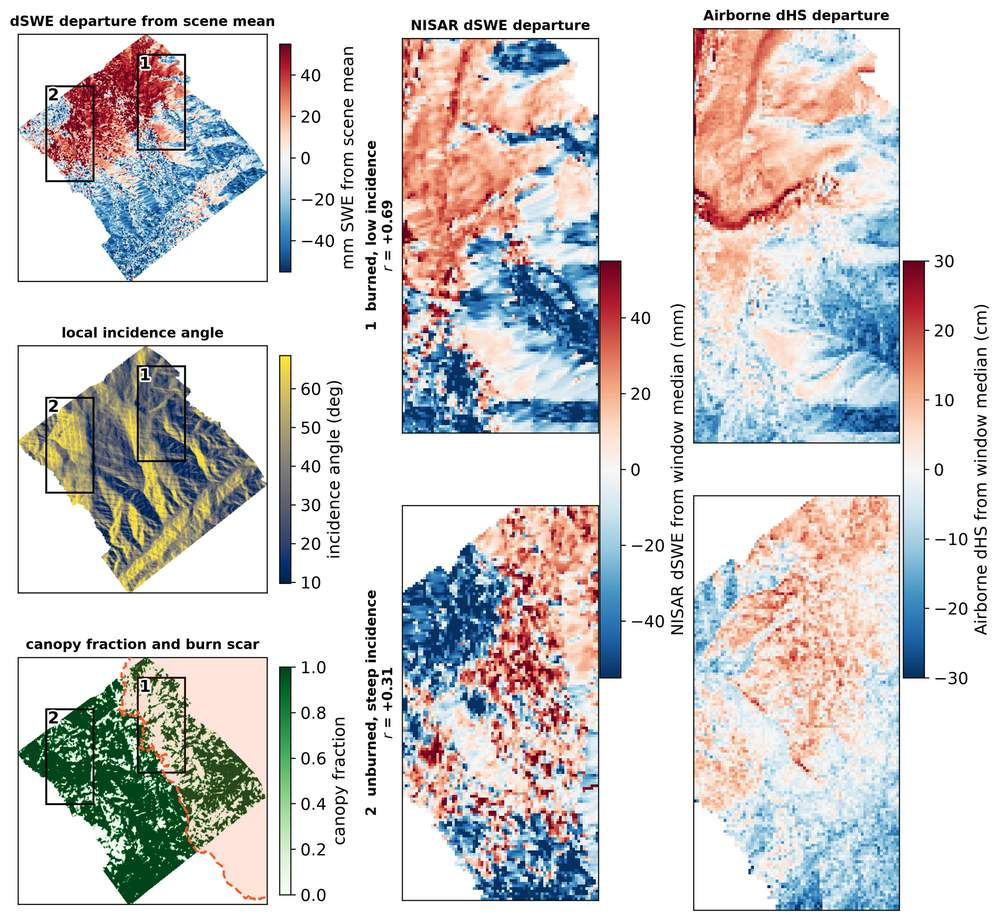

In [12]:
zach_fig3_bytes = subprocess.check_output([
    "git", "-C", str(reference_repo), "show", "HEAD:figures/fig3_subscenes.png"
])
display_compact_plot(zach_fig3_bytes, "Original Zach Figure 3 20 m subscenes from Git")

## Interpretation and availability

The 147 kg/m³ anchor sets the absolute dSWE level, but centered RMSD is calculated after removing the median dSWE-minus-lidar difference separately within each coherence subset, matching the paper's statistic. Fitted density is the regression slope and is independent of an additive reference offset. Confirm lidar nodata semantics and valid-pixel count before interpreting numerical differences. Zach states that correction screens carried in the GUNW are not applied; this notebook follows that choice.

Analysis code and pair census are in the linked GitHub repository. NIVAL lidar is distributed by NSIDC and the GUNW by ASF at the DOI links above. SNOTEL is available from NRCS. Freeman station measurements are available from the authors on request. The ancillary figures and other datasets are outside this NISAR-only port.